<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/01_Notion_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review Scrapping**

## **📱Scraped Application**

- **App Name:** Notion – Notes, Tasks, AI  
- **Google Play Link:** https://play.google.com/store/apps/details?id=notion.id&hl=id  
- **App ID:** notion.id  

## **🎯 Objective**

This project aims to retrieve user reviews from the Notion application on the Google Play Store, apply language filtering to retain only English reviews, and store the processed data in CSV format for further analytical tasks such as Exploratory Data Analysis (EDA), preprocessing, and sentiment analysis.

## **⚙️ Process Description**

| Stage | Description |
|------|------------|
| Data Collection | User reviews were extracted from the Notion application on Google Play using the `google_play_scraper` library, filtered in English, and sorted by the newest. |
| Data Structuring | The raw data was converted into a structured format using pandas DataFrame, with each attribute organized into separate columns. |
| Data Storage | The processed dataset was saved as a CSV file named `df_review_notion.csv` for further use. |
| Column Selection | Relevant columns such as content, score, thumbsUpCount, reviewCreatedVersion, at, replyContent, and repliedAt were selected for analysis. |
| Initial Analysis | Basic analysis was performed to examine rating distribution using value_counts() and visualized using a histogram. |

### **Instalation & Import Library**

In [1]:
!pip install google_play_scraper

In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

### **Data Scrapping**

In [3]:
from google_play_scraper import app, Sort, reviews_all

notion_reviews = reviews_all(
    'notion.id', # Google Play id for notion
    sleep_milliseconds=0,
    lang='en', # review language
    sort=Sort.NEWEST,
)

In [4]:
df_result = pd.DataFrame(np.array(notion_reviews),columns=['content'])
df_result = df_result.join(pd.DataFrame(df_result.pop('content').tolist()))
df_result.to_csv(r'review_notion_raw.csv', index=False)

In [5]:
df_result

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,acfbcf53-ca8a-40b3-a92e-d94447da864f,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"had a payment issue, the SAV solved it quickly.",5,0,None,2026-04-29 16:35:03,None,NaT,None
1,ae9206ec-742a-417e-a83a-7c5536ec50f5,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,None,NaT,0.6.3809
2,9f587909-e254-4d20-a2f1-440cd989727d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"I loved this app, but my documents keep going ...",3,0,None,2026-04-29 10:38:49,None,NaT,None
3,ab75d7d3-340f-40a9-aa88-23bed04f99a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,powerful (All in 1). but new ke liye itna jada...,1,0,None,2026-04-29 09:22:59,None,NaT,None
4,28454e31-ae36-41d5-b1b5-11ee19f36fa7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,None,NaT,0.6.3803
...,...,...,...,...,...,...,...,...,...,...,...
23109,01fbf110-9b5b-440d-94a5-a39d74f3ad47,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Notion is not only the best organizing, note ...",5,7,0.3.3,2018-06-07 08:26:06,None,NaT,0.3.3
23110,07558cfb-7ae0-4c1a-9a41-36d8070d6084,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Give me an API!,5,2,0.3.3,2018-05-18 19:18:47,None,NaT,0.3.3
23111,e9b5bead-1eda-474b-8920-2cb6cdb52fa9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Ignore anything other than 5-star- it's silly ...,5,10,0.3.3,2018-05-18 07:57:14,None,NaT,0.3.3
23112,89370fdf-af49-4ab0-8392-8e16cab16287,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Superb web app, now made easier to use. Hard t...",5,8,0.3.3,2018-04-24 14:15:34,None,NaT,0.3.3


In [6]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23114 entries, 0 to 23113
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              23114 non-null  object        
 1   userName              23114 non-null  object        
 2   userImage             23114 non-null  object        
 3   content               23114 non-null  object        
 4   score                 23114 non-null  int64         
 5   thumbsUpCount         23114 non-null  int64         
 6   reviewCreatedVersion  20248 non-null  object        
 7   at                    23114 non-null  datetime64[ns]
 8   replyContent          161 non-null    object        
 9   repliedAt             161 non-null    datetime64[ns]
 10  appVersion            20248 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.9+ MB


In [7]:
# Filtered Columns
df_analysis = df_result.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"had a payment issue, the SAV solved it quickly.",5,0,None,2026-04-29 16:35:03,None,NaT
1,"Using Notion on a high-end phone, but it keeps...",1,0,0.6.3809,2026-04-29 14:15:07,None,NaT
2,"I loved this app, but my documents keep going ...",3,0,None,2026-04-29 10:38:49,None,NaT
3,powerful (All in 1). but new ke liye itna jada...,1,0,None,2026-04-29 09:22:59,None,NaT
4,Very bad mobile experience. Everything is so s...,1,0,0.6.3803,2026-04-28 20:29:03,None,NaT
...,...,...,...,...,...,...,...
23109,"Notion is not only the best organizing, note ...",5,7,0.3.3,2018-06-07 08:26:06,None,NaT
23110,Give me an API!,5,2,0.3.3,2018-05-18 19:18:47,None,NaT
23111,Ignore anything other than 5-star- it's silly ...,5,10,0.3.3,2018-05-18 07:57:14,None,NaT
23112,"Superb web app, now made easier to use. Hard t...",5,8,0.3.3,2018-04-24 14:15:34,None,NaT


### **Exploratory Data Analysis**

In [8]:
# Distribution of reviews score
df_result['score'].value_counts()

,count
score,
5,11805
1,3677
4,3113
3,2628
2,1891


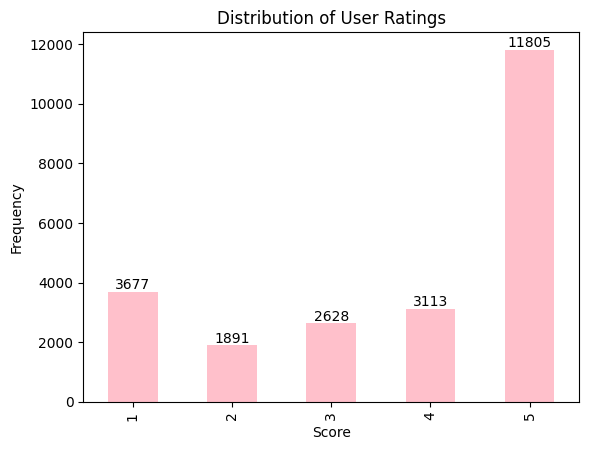

In [10]:
#Visualization
ax = df_result['score'].value_counts().sort_index().plot(kind='bar', color='#FFC0CB')

for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height(),
            int(i.get_height()), ha='center', va='bottom')

plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')
plt.show()